#**KNOWLEDGE GRAPH EXPLOITATION**

This is the notebook associated with the assignment **Knowledge Graph Exploitation**. In LearnSQL you can find the assignment statament, so please carefully read it while following the scripts, answering all the questions and compleating the tasks. Remember to change the **Runtime** settings to include GPU access.

Before starting, we will install and import the required libraries:

In [1]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install pykeen
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## **Creating the Knowledge Graph**

In [3]:
import numpy as np
from pykeen.triples import TriplesFactory
from torch_geometric.datasets import Planetoid


dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

edge_index = data.edge_index

# Convert to numpy
heads = edge_index[0].cpu().numpy()
tails = edge_index[1].cpu().numpy()

# Create string triples
triples = np.array([
    [f"paper_{h}", "cites", f"paper_{t}"]
    for h, t in zip(heads, tails)
])

tf = TriplesFactory.from_labeled_triples(triples)

training, testing, validation = tf.split([0.8, 0.1, 0.1],random_state=2026)

c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing...
c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\berta\AppData\Local\Python\

# A.1 The Most Basic Model

TransE is the simplest translational KGE model. It learns an embedding vector for each entity and each relation such that, for every true triple (h, r, t), the equation $h + r \approx t$ holds in the embedding space. In this case, the PubMed citation graph contains 19717 papers and a single relation type ("cites"), so the model learns 19717 entity vectors and one relation vector.

The model is trained using PyKEEN's pipeline with the following configuration: embedding dimension of 64, 100 epochs, Adam optimizer with learning rate 0.001, margin ranking loss with margin 1.0, and uniform negative sampling with 1 negative sample per positive triple.

Once trained, a paper is chosen (paper_0) and its citations are read directly from the graph. The embeddings of the cited papers are averaged to obtain a representative "citation target" vector. Then, using TransE's equation in reverse, the ideal head embedding is computed as $x = avg(t_i) - r$. This vector represents the embedding of a hypothetical paper that would cite works similar to those cited by paper_0. Since this exact vector does not correspond to any real paper, the closest real paper in the embedding space is retrieved using Euclidean distance, excluding paper_0 itself. Finally, the relevant embeddings are projected to 2D using PCA for visualization.

In [ ]:
# Training TransE

from pykeen.pipeline import pipeline

result = pipeline(
    training=training,
    testing=testing,
    validation=validation,
    model='TransE',
    model_kwargs=dict(embedding_dim=64),
    epochs=100,
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.001),
    loss='MarginRankingLoss',
    loss_kwargs=dict(margin=1.0),
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=1),
    random_seed=42,
)

# Extract embeddings
model = result.model
entity_embs = model.entity_representations[0](indices=None).detach().cpu().numpy()
relation_embs = model.relation_representations[0](indices=None).detach().cpu().numpy()
r = relation_embs[0]

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training epochs on cuda:0:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 2.42s seconds


In [ ]:
# Pick a paper and find its citations
paper_id = 'paper_0'
paper_idx = tf.entity_to_id[paper_id]
cited_papers = triples[triples[:, 0] == paper_id][:, 2]
print(f"{paper_id} cites: {cited_papers}")

# Use 5 cited papers for cleaner visualization
cited_indices_subset = [tf.entity_to_id[p] for p in cited_papers]

# Average the cited papers' embeddings
avg_tail = entity_embs[cited_indices_subset].mean(axis=0)

# Compute x = avg - r
x = avg_tail - r

# Find closest real paper, excluding paper_0
from scipy.spatial.distance import cdist
distances = cdist(x.reshape(1, -1), entity_embs, metric='euclidean')[0]
distances[paper_idx] = float('inf')
closest_idx = distances.argmin()
closest_emb = entity_embs[closest_idx]

id_to_entity = {v: k for k, v in tf.entity_to_id.items()}
print(f"Closest paper: {id_to_entity[closest_idx]}")
print(f"Distance: {distances[closest_idx]:.4f}")

paper_0 cites: ['paper_1378' 'paper_1544' 'paper_6092' 'paper_7636' 'paper_14442']
Closest paper: paper_6092
Distance: 0.6365


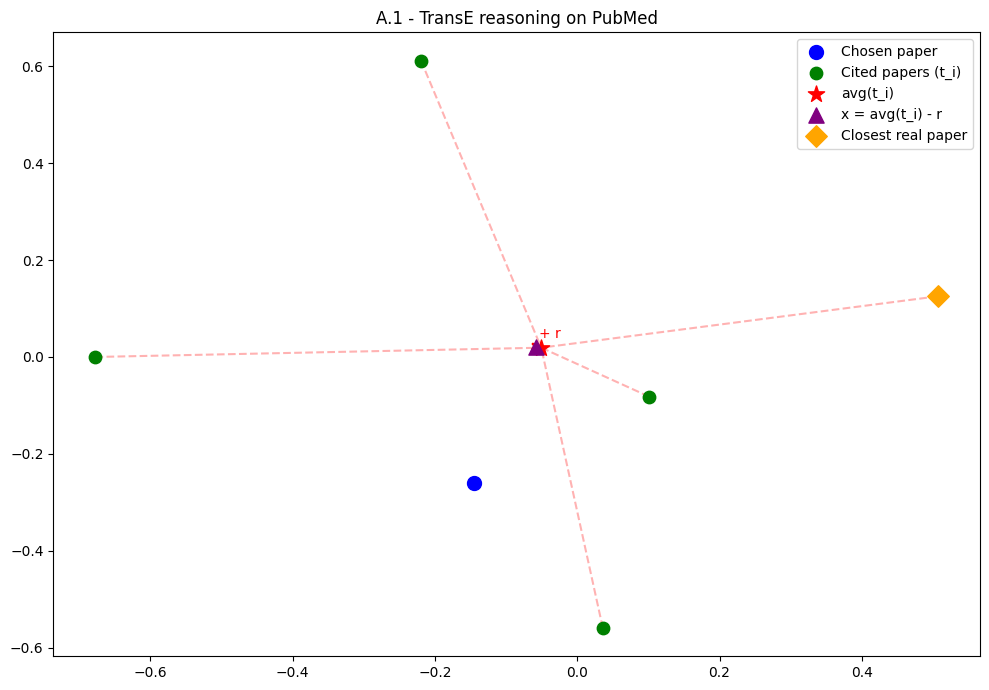

In [ ]:
# 2D Sketch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

all_vecs = np.vstack([
    entity_embs[paper_idx],
    entity_embs[cited_indices_subset],
    avg_tail,
    x,
    closest_emb,
])

pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(all_vecs)
n = len(cited_papers)

plt.figure(figsize=(10, 7))

# Original paper
plt.scatter(*vecs_2d[0], c='blue', s=100, zorder=5)
plt.scatter([], [], c='blue', s=100, label='Chosen paper')

# Cited papers
for i in range(1, 1 + n):
    plt.scatter(*vecs_2d[i], c='green', s=80, zorder=5)
plt.scatter([], [], c='green', s=80, label='Cited papers (t_i)')

# Average of cited
avg_2d = vecs_2d[1 + n]
plt.scatter(*avg_2d, c='red', s=150, marker='*', zorder=5)
for i in range(1, 1 + n):
    plt.plot([vecs_2d[i][0], avg_2d[0]], [vecs_2d[i][1], avg_2d[1]], 'r--', alpha=0.3)
plt.scatter([], [], c='red', s=150, marker='*', label='avg(t_i)')

# x = avg - r
x_2d = vecs_2d[1 + n + 1]
plt.scatter(*x_2d, c='purple', s=120, marker='^', zorder=5)
plt.annotate('', xy=avg_2d, xytext=x_2d,
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
plt.annotate('+ r', ((x_2d[0]+avg_2d[0])/2, (x_2d[1]+avg_2d[1])/2 + 0.02),
             fontsize=10, color='red')
plt.scatter([], [], c='purple', s=120, marker='^', label='x = avg(t_i) - r')

# Closest real paper
closest_2d = vecs_2d[-1]
plt.scatter(*closest_2d, c='orange', s=120, marker='D', zorder=5)
plt.scatter([], [], c='orange', s=120, marker='D', label='Closest real paper')

plt.title('A.1 - TransE reasoning on PubMed')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Chosen paper: {paper_id}")
print(f"Papers it cites (subset): {list(cited_papers_subset)}")
print(f"Closest paper found: {id_to_entity[closest_idx]}")
print(f"Distance to x: {distances[closest_idx]:.4f}")

Chosen paper: paper_0
Papers it cites (subset): [np.str_('paper_1378'), np.str_('paper_1544'), np.str_('paper_6092'), np.str_('paper_7636'), np.str_('paper_14442')]
Closest paper found: paper_6092
Distance to x: 0.6365


The retrieved paper is the paper_6092, which according to the TransE embedding space is the paper most likely to cite similar works as paper_0. The 2D projection shows that the average of the cited papers' embeddings and the computed $x = avg - r$ are very close to each other, indicating that the learned relation vector r has a small magnitude. This is expected in a Knowledge Graph with a single relation type, since TransE does not need a large displacement to distinguish different relations. Note that PCA plot is used for visualization since the embeddings live in a 64-dimension space.

## **A.3 Training KGEs**

In this section, different KGE models are trained on the PubMed citation graph. Eight models are used, four translational (TransE, TransH, TransR, RotatE) and four semantic (DistMult, ComplEx, RESCAL, HolE). Translational models represent relations as geometric transformations (translations, rotations, projections) on the embedding vectors, while semantic models capture relations through multiplicative or bilinear interactions.

First, all models are compared under the same baseline configuration. Then, three hyperparameters are explored: embedding dimension, number of negative samples per positive triple, and either the loss margin (for translational models) or the loss function (for semantic models). Hits@1, Hits@3, and MRR are reported for each experiment.

In [4]:
# Global best model tracker
from pykeen.pipeline import pipeline
import pandas as pd

translational_models = ['TransE', 'TransH', 'TransR', 'RotatE']
semantic_models = ['DistMult', 'ComplEx', 'RESCAL', 'HolE']
all_models = translational_models + semantic_models

best_mrr = 0
best_model_name = None
best_model_config = None
best_result = None

def track_best(result, model_name, config_str):
    global best_mrr, best_model_name, best_model_config, best_result
    metrics = result.metric_results.to_dict()
    mrr = metrics['both']['realistic']['inverse_harmonic_mean_rank']
    if mrr > best_mrr:
        best_mrr = mrr
        best_model_name = model_name
        best_model_config = config_str
        best_result = result
    return {
        'Hits@1': metrics['both']['realistic']['hits_at_1'],
        'Hits@3': metrics['both']['realistic']['hits_at_3'],
        'MRR': mrr,
    }

In [5]:
# Experiment 1: Model comparison
# All 8 models with the same baseline config
# Loss is not specified so PyKEEN picks the default for each model

baseline_results = {}

for model_name in all_models:
    print(f"\nTraining {model_name}...")
    result = pipeline(
        training=training,
        testing=testing,
        validation=validation,
        model=model_name,
        model_kwargs=dict(embedding_dim=64),
        epochs=100,
        optimizer='Adam',
        optimizer_kwargs=dict(lr=0.001),
        negative_sampler='basic',
        negative_sampler_kwargs=dict(num_negs_per_pos=1),
        random_seed=42,
    )
    baseline_results[model_name] = track_best(result, model_name, 'baseline')

df_baseline = pd.DataFrame(baseline_results).T
print("\nModel Comparison")
print(df_baseline.to_string())

No cuda devices were available. The model runs on CPU



Training TransE...


c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 100/100 [02:23<00:00,  1.44s/epoch, loss=0.00422, prev_loss=0.00474]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:33<00:00, 261triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 34.39s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation


Training TransH...


Training epochs on cpu: 100%|██████████| 100/100 [04:01<00:00,  2.42s/epoch, loss=0.152, prev_loss=0.155]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:23<00:00, 379triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 23.80s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


...


Training RESCAL...


Training epochs on cpu: 100%|██████████| 100/100 [04:23<00:00,  2.64s/epoch, loss=1.09, prev_loss=1.09]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:12<00:00, 684triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 13.40s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Training HolE...


Training epochs on cpu: 100%|██████████| 100/100 [03:11<00:00,  1.91s/epoch, loss=0.00498, prev_loss=0.00543]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:23<00:00, 383triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 23.52s seconds



Model Comparison
            Hits@1    Hits@3       MRR
TransE    0.000000  0.371968  0.219500
TransH    0.003948  0.019289  0.026090
TransR    0.000113  0.002482  0.005506
RotatE    0.600959  0.706543  0.669240
DistMult  0.364016  0.476086  0.447343
ComplEx   0.001354  0.004174  0.015435
RESCAL    0.000000  0.000056  0.000252
HolE      0.191596  0.306261  0.278465


In [6]:
# Experiment 2: Embedding dimension
# All 8 models, varying dim = 32, 64, 128, 256

dims = [32, 64, 128, 256]
dim_results = {}

for model_name in all_models:
    for dim in dims:
        print(f"\nTraining {model_name} with dim={dim}...")
        result = pipeline(
            training=training,
            testing=testing,
            validation=validation,
            model=model_name,
            model_kwargs=dict(embedding_dim=dim),
            epochs=30,
            optimizer='Adam',
            optimizer_kwargs=dict(lr=0.001),
            negative_sampler='basic',
            negative_sampler_kwargs=dict(num_negs_per_pos=1),
            random_seed=42,
        )
        metrics = track_best(result, model_name, f'dim={dim}')
        dim_results[f'{model_name}_dim={dim}'] = {
            'Model': model_name,
            'Dim': dim,
            **metrics,
        }

df_dims = pd.DataFrame(dim_results).T
print("\nEmbedding Dimension Effect")
print(df_dims.to_string())

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Training TransE with dim=32...


Training epochs on cpu: 100%|██████████| 30/30 [00:32<00:00,  1.08s/epoch, loss=0.0355, prev_loss=0.0386]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:29<00:00, 297triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 30.30s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Training TransE with dim=64...


Training epochs on cpu: 100%|██████████| 30/30 [00:47<00:00,  1.59s/epoch, loss=0.0123, prev_loss=0.0127]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:35<00:00, 248triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 36.22s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


...


Training HolE with dim=128...


Training epochs on cpu: 100%|██████████| 30/30 [01:37<00:00,  3.26s/epoch, loss=0.00809, prev_loss=0.00721]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:37<00:00, 237triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 37.74s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Training HolE with dim=256...


Training epochs on cpu: 100%|██████████| 30/30 [03:06<00:00,  6.21s/epoch, loss=0.00717, prev_loss=0.00696]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [01:13<00:00, 120triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 73.93s seconds



Embedding Dimension Effect
                     Model  Dim    Hits@1    Hits@3       MRR
TransE_dim=32       TransE   32       0.0  0.025494   0.03378
TransE_dim=64       TransE   64       0.0  0.121997  0.095324
TransE_dim=128      TransE  128       0.0  0.286576  0.172139
TransE_dim=256      TransE  256       0.0  0.443542  0.244628
TransH_dim=32       TransH   32   0.00062  0.001579  0.003586
TransH_dim=64       TransH   64  0.002876  0.011675  0.016461
TransH_dim=128      TransH  128  0.002933  0.025832  0.028747
TransH_dim=256      TransH  256  0.003046  0.024817   0.02838
TransR_dim=32       TransR   32       0.0  0.012916  0.017771
TransR_dim=64       TransR   64       0.0  0.001918  0.005095
TransR_dim=128      TransR  128  0.000226   0.00062  0.001272
TransR_dim=256      TransR  256  0.000169  0.000226   0.00125
RotatE_dim=32       RotatE   32  0.304456  0.398985  0.373292
RotatE_dim=64       RotatE   64  0.520699  0.617936  0.587263
RotatE_dim=128      RotatE  128  0.591765 

In [7]:
# Experiment 3: Number of negative samples
# All 8 models, varying negs = 1, 5, 10, 20

neg_samples = [1, 5, 10, 20]
neg_results = {}

for model_name in all_models:
    for neg in neg_samples:
        print(f"\nTraining {model_name} with num_negs={neg}...")
        result = pipeline(
            training=training,
            testing=testing,
            validation=validation,
            model=model_name,
            model_kwargs=dict(embedding_dim=64),
            epochs=30,
            optimizer='Adam',
            optimizer_kwargs=dict(lr=0.001),
            negative_sampler='basic',
            negative_sampler_kwargs=dict(num_negs_per_pos=neg),
            random_seed=42,
        )
        metrics = track_best(result, model_name, f'negs={neg}')
        neg_results[f'{model_name}_negs={neg}'] = {
            'Model': model_name,
            'Negs': neg,
            **metrics,
        }

df_negs = pd.DataFrame(neg_results).T
print("\nNegative Samples Effect")
print(df_negs.to_string())

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Training TransE with num_negs=1...


Training epochs on cpu: 100%|██████████| 30/30 [00:41<00:00,  1.40s/epoch, loss=0.0123, prev_loss=0.0127]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:34<00:00, 255triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 35.10s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Training TransE with num_negs=5...


Training epochs on cpu: 100%|██████████| 30/30 [00:44<00:00,  1.50s/epoch, loss=0.00519, prev_loss=0.00507]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:34<00:00, 256triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 34.92s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


...


Training HolE with num_negs=10...


Training epochs on cpu: 100%|██████████| 30/30 [01:03<00:00,  2.10s/epoch, loss=0.00266, prev_loss=0.00284]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:22<00:00, 392triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 22.94s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Training HolE with num_negs=20...


Training epochs on cpu: 100%|██████████| 30/30 [01:12<00:00,  2.42s/epoch, loss=0.00215, prev_loss=0.00222]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:22<00:00, 390triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 23.10s seconds



Negative Samples Effect
                     Model Negs    Hits@1    Hits@3       MRR
TransE_negs=1       TransE    1       0.0  0.121997  0.095324
TransE_negs=5       TransE    5       0.0  0.143091  0.108969
TransE_negs=10      TransE   10       0.0  0.192217  0.137109
TransE_negs=20      TransE   20       0.0  0.180936  0.130955
TransH_negs=1       TransH    1  0.002876  0.011675  0.016461
TransH_negs=5       TransH    5  0.002707  0.020192  0.025054
TransH_negs=10      TransH   10   0.00203  0.013367  0.019462
TransH_negs=20      TransH   20    0.0022  0.020756  0.027607
TransR_negs=1       TransR    1       0.0  0.001918  0.005095
TransR_negs=5       TransR    5       0.0  0.012465  0.020006
TransR_negs=10      TransR   10       0.0  0.012352  0.019079
TransR_negs=20      TransR   20       0.0  0.013988  0.022115
RotatE_negs=1       RotatE    1  0.520699  0.617936  0.587263
RotatE_negs=5       RotatE    5  0.598928  0.702933  0.665553
RotatE_negs=10      RotatE   10  0.632487  0.

In [8]:
# Experiment 4a: Loss margin (translational models only)
# Margin controls the minimum desired distance between positive and negative scores

margins = [0.5, 1.0, 2.0, 5.0]
margin_results = {}

for model_name in translational_models:
    for margin in margins:
        print(f"\nTraining {model_name} with margin={margin}...")
        result = pipeline(
            training=training,
            testing=testing,
            validation=validation,
            model=model_name,
            model_kwargs=dict(embedding_dim=64),
            epochs=30,
            optimizer='Adam',
            optimizer_kwargs=dict(lr=0.001),
            loss='MarginRankingLoss',
            loss_kwargs=dict(margin=margin),
            negative_sampler='basic',
            negative_sampler_kwargs=dict(num_negs_per_pos=1),
            random_seed=42,
        )
        metrics = track_best(result, model_name, f'margin={margin}')
        margin_results[f'{model_name}_margin={margin}'] = {
            'Model': model_name,
            'Margin': margin,
            **metrics,
        }

df_margins = pd.DataFrame(margin_results).T
print("\nMargin Effect (Translational Models)")
print(df_margins.to_string())

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Training TransE with margin=0.5...


Training epochs on cpu: 100%|██████████| 30/30 [00:43<00:00,  1.44s/epoch, loss=0.00924, prev_loss=0.00947]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:33<00:00, 262triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 34.10s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Training TransE with margin=1.0...


Training epochs on cpu: 100%|██████████| 30/30 [00:42<00:00,  1.43s/epoch, loss=0.0123, prev_loss=0.0127]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:34<00:00, 260triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 34.42s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


...


Training RotatE with margin=2.0...


Training epochs on cpu: 100%|██████████| 30/30 [01:14<00:00,  2.47s/epoch, loss=0.187, prev_loss=0.206]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:44<00:00, 197triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 45.32s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Training RotatE with margin=5.0...


Training epochs on cpu: 100%|██████████| 30/30 [01:13<00:00,  2.46s/epoch, loss=2.13, prev_loss=2.2] 
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:44<00:00, 198triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 45.15s seconds



Margin Effect (Translational Models)
                    Model Margin    Hits@1    Hits@3       MRR
TransE_margin=0.5  TransE    0.5       0.0  0.026734  0.030509
TransE_margin=1.0  TransE    1.0       0.0  0.121997  0.095324
TransE_margin=2.0  TransE    2.0       0.0  0.392611  0.230131
TransE_margin=5.0  TransE    5.0       0.0  0.395037  0.226096
TransH_margin=0.5  TransH    0.5  0.002594  0.038973    0.0407
TransH_margin=1.0  TransH    1.0  0.002876  0.011675  0.016461
TransH_margin=2.0  TransH    2.0  0.000846  0.003102  0.005703
TransH_margin=5.0  TransH    5.0  0.000451  0.001184  0.002865
TransR_margin=0.5  TransR    0.5  0.000226  0.001184  0.003503
TransR_margin=1.0  TransR    1.0       0.0  0.001918  0.005095
TransR_margin=2.0  TransR    2.0  0.000564  0.001805   0.00447
TransR_margin=5.0  TransR    5.0  0.000564  0.001805   0.00447
RotatE_margin=0.5  RotatE    0.5  0.558094  0.670333  0.628727
RotatE_margin=1.0  RotatE    1.0  0.520699  0.617936  0.587263
RotatE_margin=2.0

In [9]:
# Experiment 4b: Loss function (semantic models only)
# Semantic models don't use margin. Instead different loss functions are explored

losses = ['BCEWithLogitsLoss', 'SoftplusLoss', 'CrossEntropyLoss', 'NSSALoss']
loss_results = {}

for model_name in semantic_models:
    for loss_name in losses:
        print(f"\nTraining {model_name} with loss={loss_name}...")
        try:
            result = pipeline(
                training=training,
                testing=testing,
                validation=validation,
                model=model_name,
                model_kwargs=dict(embedding_dim=64),
                epochs=30,
                optimizer='Adam',
                optimizer_kwargs=dict(lr=0.001),
                loss=loss_name,
                negative_sampler='basic',
                negative_sampler_kwargs=dict(num_negs_per_pos=1),
                random_seed=42,
            )
            metrics = track_best(result, model_name, f'loss={loss_name}')
            loss_results[f'{model_name}_{loss_name}'] = {
                'Model': model_name,
                'Loss': loss_name,
                **metrics,
            }
        except Exception as e:
            print(f"  Failed: {e}")
            loss_results[f'{model_name}_{loss_name}'] = {
                'Model': model_name,
                'Loss': loss_name,
                'Hits@1': None,
                'Hits@3': None,
                'MRR': None,
            }

df_losses = pd.DataFrame(loss_results).T
print("\nLoss Function Effect (Semantic Models)")
print(df_losses.to_string())

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Training DistMult with loss=BCEWithLogitsLoss...


Training epochs on cpu: 100%|██████████| 30/30 [00:45<00:00,  1.51s/epoch, loss=0.693, prev_loss=0.693]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:08<00:00, 992triple/s]  
INFO:pykeen.evaluation.evaluator:Evaluation took 9.28s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)



Training DistMult with loss=SoftplusLoss...


Training epochs on cpu: 100%|██████████| 30/30 [00:45<00:00,  1.53s/epoch, loss=0.693, prev_loss=0.693]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:09<00:00, 983triple/s]  
INFO:pykeen.evaluation.evaluator:Evaluation took 9.41s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


...


Training HolE with loss=CrossEntropyLoss...


Training epochs on cpu: 100%|██████████| 30/30 [00:52<00:00,  1.75s/epoch, loss=0.00593, prev_loss=0.00609]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:22<00:00, 393triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 22.91s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Training HolE with loss=NSSALoss...


Training epochs on cpu: 100%|██████████| 30/30 [00:54<00:00,  1.81s/epoch, loss=0.17, prev_loss=0.184] 
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:22<00:00, 391triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 23.01s seconds



Loss Function Effect (Semantic Models)
                               Model               Loss    Hits@1    Hits@3       MRR
DistMult_BCEWithLogitsLoss  DistMult  BCEWithLogitsLoss       0.0  0.000113  0.000419
DistMult_SoftplusLoss       DistMult       SoftplusLoss  0.000056  0.000169  0.000562
DistMult_CrossEntropyLoss   DistMult   CrossEntropyLoss  0.000113  0.000169  0.000613
DistMult_NSSALoss           DistMult           NSSALoss  0.000056  0.000056  0.000467
ComplEx_BCEWithLogitsLoss    ComplEx  BCEWithLogitsLoss  0.000113  0.000508  0.001247
ComplEx_SoftplusLoss         ComplEx       SoftplusLoss  0.000113  0.000508  0.001247
ComplEx_CrossEntropyLoss     ComplEx   CrossEntropyLoss  0.000113   0.00062  0.001406
ComplEx_NSSALoss             ComplEx           NSSALoss  0.000056  0.000113  0.000507
RESCAL_BCEWithLogitsLoss      RESCAL  BCEWithLogitsLoss       0.0       0.0  0.000209
RESCAL_SoftplusLoss           RESCAL       SoftplusLoss  0.000113  0.000169  0.000371
RESCAL_CrossEn

In [10]:
# Best model embeddings
print(f"\nBest overall model: {best_model_name} ({best_model_config})")
print(f"MRR: {best_mrr:.4f}")


Best overall model: RotatE (negs=20)
MRR: 0.7100


**RotatE** is the clear best model overall (MRR=0.669), far ahead of all others, thanks to its ability to model asymmetric relations through rotations in complex space. **DistMult** and **HolE** perform reasonably, while **TransE**, despite being a simple baseline, achieves decent Hits@3 but zero Hits@1. This is because with a single relation type, all heads are mapped to similar positions, making exact rank-1 prediction very difficult. **TransH**, **TransR**, **ComplEx**, and **RESCAL** perform poorly on this KG, likely due to overfitting or unsuitable inductive biases for a single-relation homogeneous graph.

For hyperparameters, increasing **negative samples** generally improves results (especially for RotatE and HolE), since more negatives provide a richer training signal. The **margin** effect varies by model: TransE improves with higher margins (up to 2.0), while RotatE degrades sharply. In other words, a smaller margin (0.5) works best for RotatE, suggesting it already separates positives and negatives well and a large margin destabilizes training. The **loss function** experiment shows that semantic models are largely insensitive to the choice of loss on this KG, with most performing near zero except HolE, where BCEWithLogitsLoss and SoftplusLoss tie as best.

## **A.4 Negative Sampling**

In PyKEEN, two negative sampling strategies are available: Uniform (basic) and Bernoulli. When generating a negative triple from a positive (h, r, t), the sampler must decide whether to corrupt the head or the tail. Uniform sampling corrupts head and tail with equal probability (50/50). Bernoulli sampling adjusts these probabilities based on the average number of tails per head (tph) and heads per tail (hpt) for each relation. The idea is to corrupt the side that has more diversity, since it is more likely to produce a true negative.

For a relation r, the corruption probabilities are:
- P(corrupt head) = tph / (tph + hpt)
- P(corrupt tail) = hpt / (tph + hpt)

Since our KG has a single relation ("cites"), we compute these values and discuss whether Bernoulli sampling provides any benefit over Uniform sampling.

In [ ]:
# Compute tph and hpt for the cites relation

# tph = average number of tails per head
# For each unique head, count how many tails it connects to, then average
heads = triples[:, 0]
tails = triples[:, 2]

unique_heads = np.unique(heads)
unique_tails = np.unique(tails)

# tph: for each head, how many different tails?
tails_per_head = {}
for h, t in zip(heads, tails):
    if h not in tails_per_head:
        tails_per_head[h] = set()
    tails_per_head[h].add(t)
tph = np.mean([len(v) for v in tails_per_head.values()])

# hpt: for each tail, how many different heads?
heads_per_tail = {}
for h, t in zip(heads, tails):
    if t not in heads_per_tail:
        heads_per_tail[t] = set()
    heads_per_tail[t].add(h)
hpt = np.mean([len(v) for v in heads_per_tail.values()])

print(f"tph (avg tails per head): {tph:.4f}")
print(f"hpt (avg heads per tail): {hpt:.4f}")

# Bernoulli corruption probabilities
p_corrupt_head = tph / (tph + hpt)
p_corrupt_tail = hpt / (tph + hpt)

print(f"\nBernoulli corruption probabilities:")
print(f"P(corrupt head) = {p_corrupt_head:.4f}")
print(f"P(corrupt tail) = {p_corrupt_tail:.4f}")

print(f"\nUniform corruption probabilities:")
print(f"P(corrupt head) = 0.5000")
print(f"P(corrupt tail) = 0.5000")

tph (avg tails per head): 4.4960
hpt (avg heads per tail): 4.4960

Bernoulli corruption probabilities:
P(corrupt head) = 0.5000
P(corrupt tail) = 0.5000

Uniform corruption probabilities:
P(corrupt head) = 0.5000
P(corrupt tail) = 0.5000


The Bernoulli corruption probabilities are exactly P(corrupt head) = P(corrupt tail) = 0.5, identical to Uniform sampling. This happens because the PubMed graph, as loaded from PyTorch Geometric, stores edges in both directions: for every (A, cites, B) there exists (B, cites, A). This makes the graph symmetric, so tph = hpt = 4.4960. As a result, the Bernoulli strategy provides no benefit over Uniform sampling in this KG.

Bernoulli sampling is designed for KGs where relations have asymmetric connectivity patterns (e.g., many-to-one relations like "born_in"), where corrupting the more diverse side produces better negatives. With a single symmetric relation, both strategies are equivalent.

## **Loading the full PubMed Dataset**

In [11]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

print(data)
print("Number of node features:", dataset.num_node_features)
print("Number of classes:", dataset.num_classes)

data = data.to('cuda' if torch.cuda.is_available() else 'cpu')

Data(x=[19717, 500], edge_index=[2, 88648], y=[19717], train_mask=[19717], val_mask=[19717], test_mask=[19717])
Number of node features: 500
Number of classes: 3


## **B.1: Let's Forget About the Graph**

In this task, the graph structure is ignored and only the TF-IDF feature vectors of the papers are used to train classifiers. The goal is to classify each paper into one of three diabetes types using standard ML algorithms. This serves as a baseline to later compare against GNN-based approaches that exploit the graph structure. Several classifiers are trained: Random Forest, SVM, Logistic Regression, and KNN.

In [12]:
import numpy as np

X = data.x.cpu().numpy()
y = data.y.cpu().numpy()

train_mask = data.train_mask.cpu().numpy()
test_mask = data.test_mask.cpu().numpy()

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

With the dataset above, train three or four simple classifiers (e.g., SVM, LR, RF, KNN...) and report the accuracy score over the test set for them.

*Note: use **sklearn** for simplicity.*

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'Accuracy': acc}
    print(f"{name}: {acc:.4f}")

df_results = pd.DataFrame(results).T
print("\nClassifier Comparison")
print(df_results.to_string())

Random Forest: 0.7390
SVM: 0.7070
Logistic Regression: 0.7290
KNN: 0.5920

Classifier Comparison
                     Accuracy
Random Forest           0.739
SVM                     0.707
Logistic Regression     0.729
KNN                     0.592


Random Forest achieves the best accuracy (73.9%), closely followed by Logistic Regression (72.9%) and SVM (70.7%). KNN performs significantly worse (59.2%), likely because the high-dimensional TF-IDF space (500 features) makes distance-based methods less effective. These results serve as a baseline, since in B.2 we will see whether exploiting the graph structure with GNNs can improve classification performance.

## **B.2: Exploiting the Graph Structure**

Now, we are going to create a GNN with graph layers and a final linear layer. Refer to the Lab Statement for more details of how to implement the architecture. You should report your designed architecutre(s) and the accuracy results.

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
# Remember to import the GNN modules you want to use


class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels): #You can change it at will (e.g., two different hidden channel sizes)
        super().__init__()

        # Your code here

    def forward(self, x, edge_index, return_embeddings=False):
        # Your code here

        return x


In [ ]:
# You are provided with a simple training and testing loop. Feel free to create your own improved versions.

gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device) #Remember to change it if you change the input parameters in the GNN class
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)


def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_gnn(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())
    return acc

for epoch in range(500):
    loss = train_gnn(gnn_model)

gnn_acc = test_gnn(gnn_model)
print("Test Accuracy:", gnn_acc)

## **B.4: The More the Merrier?**

Create new GNN models with 2, 4, 8 and 16 GNN layers and report the accuracy results. What do you observe? Why do you think it is happening?

## **B.5: What if we do  not have Initial Information?**

Train your previosuly best performing model with randomly initialized features and report the results:

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]
data.x = #Replace the features for a 256 dimension random vector
data = data.to(device)

Now, we will see how to initialize the GNN with the embeddings resulting from a Knowledge Graph Embedding Model.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]
data.x = #your_kge_embeddings (ensure they follow the same order!)
data = data.to(device)

Now, train again a GNN with the TransE embeddings as initialization:

In [ ]:
# Train

## **B.7: Where are the Embeddings?**

In this task we will obtaint the embeddings generated by our GNN architecture. First, update and retrain you best performing GNN model so that it returns the embeddings (see the lab statement for details).

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
# Remember to import the GNN/DL modules you want to use


class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels): #You can change it at will (e.g., two different hidden channel sizes)
        super().__init__()

        # Your code here

    def forward(self, x, edge_index, return_embeddings=False):
        # Your code here

        return x

gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device) #Remember to change it if you change the input parameters in the GNN class
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)


def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(500):
    loss = train_gnn(gnn_model)

Obtain the embeddings:

In [ ]:
gnn_model.eval()
embs = gnn_model(data.x, data.edge_index, return_embs=True)
embs = embs.detach().cpu().numpy()

Once you have obtained the embeddings, apply dimensionality reduction (e.g., PCA) and visualize the result by coloring each embedding with its corresponding class.

## **B.8 Embedding spaces**